# Analyse du Risque de Crédit — Mendeley Company Credit Risk Dataset

## Analyse Comparative Entre Les Modèles De Rating De Risque De Crédit
**Projet de Fin d'Année — Bank of Africa, Business Center Agadir**

---

### Dataset Description
This notebook analyzes the **Mendeley Company Data** dataset containing financial ratios
of companies for credit risk classification.

- **Source**: [Mendeley Data](https://data.mendeley.com/datasets/rv93tnjnr8/1)
- **Records**: 92,049 company observations
- **Features**: 23 financial ratios (profitability, liquidity, leverage, activity)
- **Target**: `Risk` (0=no risk, 1=risky)
- **Problem Type**: Binary Classification (~9.9% risky)

### Feature Description
| Feature | Description |
|---|---|
| PATTI | Profit After Tax / Total Income |
| PBTTI | Profit Before Tax / Total Income |
| CPTI | Cash Profit / Total Income |
| PATNW | Profit After Tax / Net Worth |
| ROCE | Return on Capital Employed |
| PATCE | Profit After Tax / Capital Employed |
| RTA | Return on Total Assets |
| PATTA | Profit After Tax / Total Assets |
| RNW | Return on Net Worth |
| CURRENT | Current Ratio |
| QUICK | Quick Ratio |
| DER | Debt-Equity Ratio |
| DSCR | Debt Service Coverage Ratio |
| CTCL | Current to Total Liabilities |
| TOLTNW | Total Liabilities / Total Net Worth |
| TTLTNW | Total Term Liabilities / Total Net Worth |
| SLSNFA | Sales / Net Fixed Assets |
| CASHCA | Cash / Current Assets |
| CRP | Credit Period (days) |
| INVCA | Inventory / Current Assets |
| LNTA | Log of Total Assets |
| LNTI | Log of Total Income |
| LNTC | Log of Total Capital |

### Models Applied (4 Paradigms)
1. **Classical Econometric**: Logistic Regression, Probit, LDA, Altman Z-Score (N/A)
2. **Machine Learning**: XGBoost, LightGBM, Random Forest, SVM, kNN, CART, MLP
3. **Structural & Market-Based**: Merton / KMV (N/A)
4. **Dynamic Stochastic**: Markov Chains & Cox PH (N/A)

## Setup

In [ ]:
import subprocess, sys
for pkg in ['lightgbm', 'shap']:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import *
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
import shap
from scipy import stats
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(12,6); plt.rcParams['font.size']=12
print('Libraries loaded.')

Libraries loaded.


---
## Phase 1 — Modeling Scope Framing

| Dimension | Description |
|---|---|
| **Scoring Type** | Acceptance Scoring — evaluate companies for credit risk |
| **Population** | 92,049 company observations with financial ratio data |
| **Time Horizon** | Cross-sectional |
| **Data Structure** | Quantitative financial ratios (23 features) |
| **Target** | Binary: Risk=1 (risky) vs Risk=0 (not risky) |
| **Imbalance** | ~9.9% risky — moderately imbalanced |

---
## Phase 2 — Data Preparation and Cleansing

In [2]:
df = pd.read_csv('Company Data.csv')
print(f'Dataset shape: {df.shape[0]:,} observations, {df.shape[1]} attributes')
df.head()

Dataset shape: 92,048 observations, 24 attributes


,Risk,PATTI,PBTTI,CPTI,PATNW,ROCE,PATCE,RTA,PATTA,RNW,...,CTCL,TOLTNW,TTLTNW,SLSNFA,CASHCA,CRP,INVCA,LNTA,LNTI,LNTC
0,0,0.0158,0.0229,0.0285,0.1208,4.81,0.0531,2.68,0.0296,10.95,...,0.32,3.10,0.47,714.51,0.3708,3005.2,0.4817,9.479512,10.052524,4.650144
1,0,-0.0936,-0.0936,0.0883,-0.1188,-6.89,-0.0747,-6.11,-0.0662,-10.96,...,0.13,0.73,0.41,137.02,0.0962,-852.9,0.2789,7.034035,6.783665,6.971575
2,0,0.0591,0.0802,0.0814,0.0695,6.74,0.0685,5.16,0.0524,6.84,...,1.45,0.34,0.00,1006.17,0.4951,22007.4,0.2273,10.301149,10.136419,4.724729
3,0,NaN,0.0066,0.0377,NaN,0.00,NaN,0.00,NaN,0.00,...,0.04,1.66,1.06,146.63,0.5168,1.0,0.2432,5.240688,4.110874,4.637637
4,1,-0.4029,-0.4016,-0.1483,-0.2602,-11.88,-0.1133,-5.11,-0.0487,-27.27,...,0.01,5.05,0.55,497.46,0.0100,-7928.2,NaN,9.734625,7.632159,7.473751


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92048 entries, 0 to 92047
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Risk     92048 non-null  int64  
 1   PATTI    76549 non-null  float64
 2   PBTTI    76538 non-null  float64
 3   CPTI     76758 non-null  float64
 4   PATNW    65340 non-null  float64
 5   ROCE     86306 non-null  float64
 6   PATCE    79024 non-null  float64
 7   RTA      90970 non-null  float64
 8   PATTA    82401 non-null  float64
 9   RNW      71093 non-null  float64
 10  CURRENT  87351 non-null  float64
 11  QUICK    87351 non-null  float64
 12  DER      69674 non-null  float64
 13  DSCR     74019 non-null  float64
 14  CTCL     87351 non-null  float64
 15  TOLTNW   69443 non-null  float64
 16  TTLTNW   69443 non-null  float64
 17  SLSNFA   89199 non-null  float64
 18  CASHCA   83545 non-null  float64
 19  CRP      91201 non-null  float64
 20  INVCA    74613 non-null  float64
 21  LNTA     905

In [4]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct%': missing_pct}).sort_values('Pct%', ascending=False)
print('Missing values:')
print(missing_df[missing_df['Missing'] > 0])
print(f'\nTotal rows with missing: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).mean():.2%})')

Missing values:
         Missing   Pct%
PATNW      26708  29.02
TOLTNW     22605  24.56
TTLTNW     22605  24.56
DER        22374  24.31
RNW        20955  22.77
DSCR       18029  19.59
INVCA      17435  18.94
PBTTI      15510  16.85
PATTI      15499  16.84
CPTI       15290  16.61
LNTI       14168  15.39
PATCE      13024  14.15
PATTA       9647  10.48
CASHCA      8503   9.24
ROCE        5742   6.24
CTCL        4697   5.10
CURRENT     4697   5.10
QUICK       4697   5.10
SLSNFA      2849   3.10
LNTA        1463   1.59
RTA         1078   1.17
CRP          847   0.92
LNTC          66   0.07

Total rows with missing: 40337 (43.82%)


In [5]:
target_col = 'Risk'
feature_cols = [c for c in df.columns if c != target_col]

# Drop rows with missing target
df = df.dropna(subset=[target_col]).reset_index(drop=True)

# Convert to numeric, coerce errors
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Impute missing with median
for c in feature_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# Handle infinites
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

df[target_col] = df[target_col].astype(int)
n_dup = df.duplicated().sum()
if n_dup > 0: df = df.drop_duplicates().reset_index(drop=True)

print(f'Final shape: {df.shape[0]:,} records')
print(f'Risk distribution:\n{df[target_col].value_counts()}')
print(f'Risk rate: {df[target_col].mean():.2%}')

Final shape: 8,279 records
Risk distribution:
Risk
0    7450
1     829
Name: count, dtype: int64
Risk rate: 10.01%


---
## Phase 3 — Sampling

In [6]:
X = df[feature_cols]; y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print(f'Train: {X_train.shape[0]:,} ({y_train.mean():.2%} risk)\nTest: {X_test.shape[0]:,} ({y_test.mean():.2%} risk)')

Train: 5,795 (10.01% risk)
Test: 2,484 (10.02% risk)


---
## Phase 4 — Variable Analysis

In [7]:
df.describe().round(3)

,Risk,PATTI,PBTTI,CPTI,PATNW,ROCE,PATCE,RTA,PATTA,RNW,...,CTCL,TOLTNW,TTLTNW,SLSNFA,CASHCA,CRP,INVCA,LNTA,LNTI,LNTC
count,8279.0,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000,...,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000,8279.000
mean,0.1,-3.244,-3.241,-1.344,-0.124,-6.732,-0.041,-2.157,-0.003,-15.996,...,0.870,10.761,4.073,2102.710,0.185,1281.292,0.475,6.196,5.984,3.484
std,0.3,84.814,84.823,26.038,4.727,121.291,1.154,50.223,0.648,412.184,...,15.908,142.778,91.663,18117.460,0.278,44596.416,0.261,2.490,2.517,2.496
min,0.0,-6396.000,-6395.000,-1315.000,-355.500,-6420.000,-56.923,-1400.000,-14.000,-31900.000,...,-0.010,0.000,-0.170,-21300.000,0.000,-527200.000,0.000,-2.303,-2.303,-2.303
25%,0.0,-0.028,-0.030,0.006,0.013,-2.825,-0.021,-2.910,-0.023,0.000,...,0.010,0.790,0.030,25.850,0.022,-44.200,0.296,4.706,4.862,2.272
50%,0.0,0.013,0.018,0.042,0.054,0.475,0.014,0.150,0.008,3.470,...,0.040,1.500,0.200,228.870,0.062,10.500,0.450,6.337,6.320,3.871
75%,0.0,0.048,0.063,0.090,0.107,5.710,0.062,4.050,0.045,9.890,...,0.170,2.680,0.580,652.855,0.194,290.300,0.629,7.867,7.562,5.068
max,1.0,25.733,4.000,4.000,138.667,1400.000,19.238,3200.000,32.000,3725.000,...,1241.000,8429.000,5698.000,611100.000,1.000,3687530.000,1.000,15.990,15.485,11.441


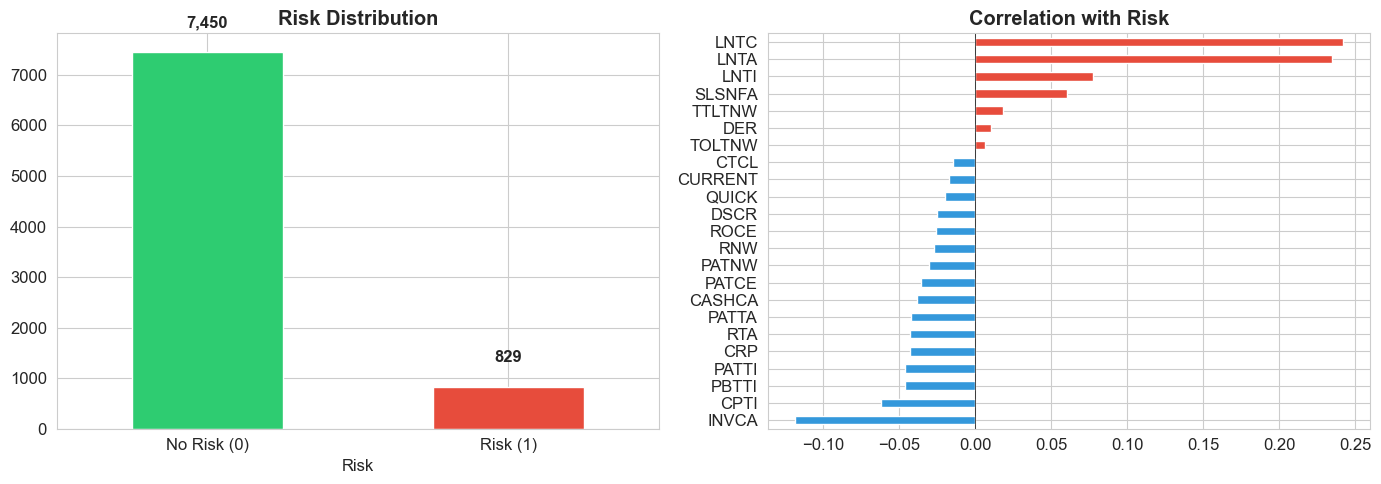

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Risk Distribution', fontweight='bold')
axes[0].set_xticklabels(['No Risk (0)','Risk (1)'], rotation=0)
for i, v in enumerate(df[target_col].value_counts()): axes[0].text(i, v+500, f'{v:,}', ha='center', fontweight='bold')

corr_target = df.corr(numeric_only=True)[target_col].drop(target_col).sort_values()
colors = ['#e74c3c' if v>0 else '#3498db' for v in corr_target]
corr_target.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title(f'Correlation with {target_col}', fontweight='bold'); axes[1].axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

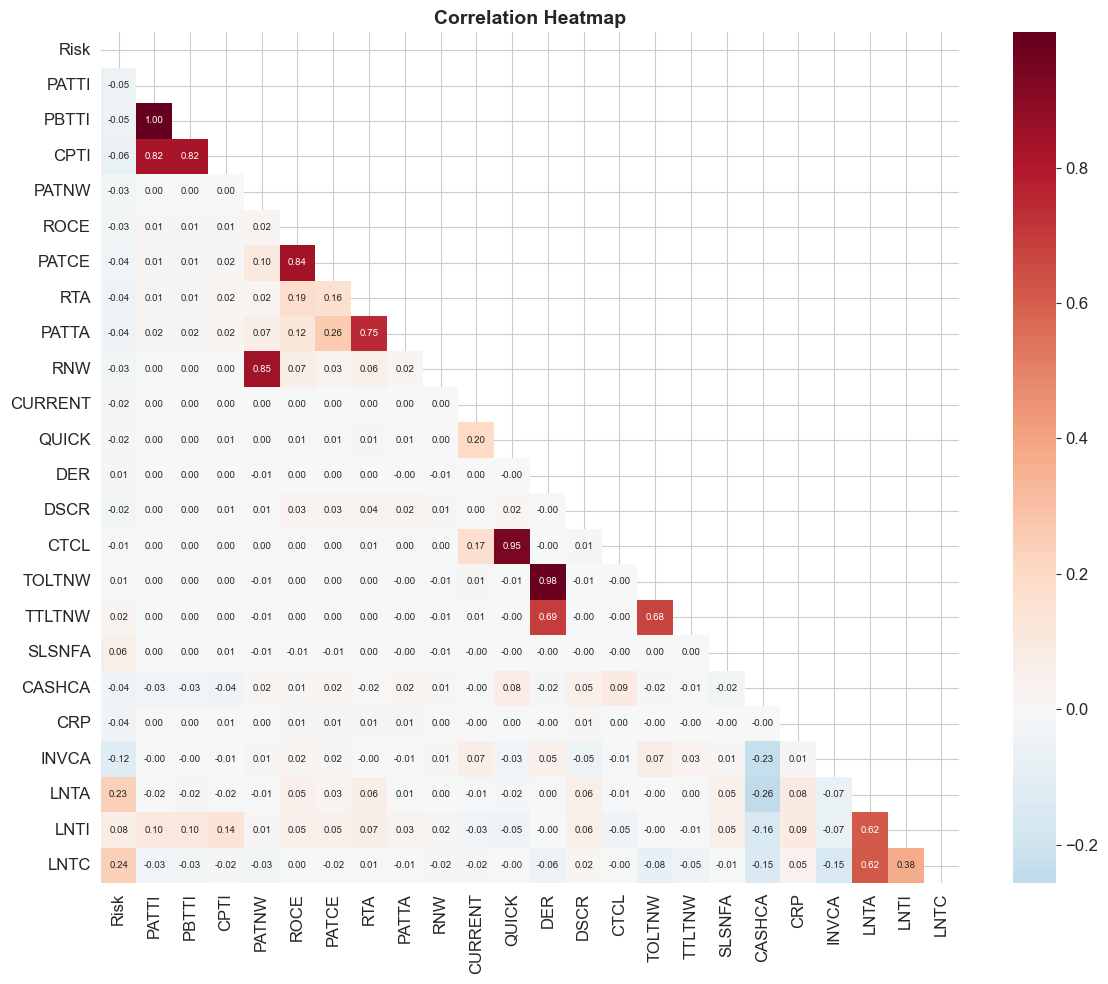

In [9]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))
sns.heatmap(df.corr(numeric_only=True), mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', annot_kws={'size':7})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold'); plt.tight_layout(); plt.show()

---
## Phase 5 — Data Pre-processing
### 5.1 Information Value (IV)

In [10]:
def calc_iv(df, feat, tgt, bins=10):
    d = df[[feat, tgt]].copy()
    try:
        if d[feat].nunique() > bins: d['b'] = pd.qcut(d[feat], q=bins, duplicates='drop')
        else: d['b'] = d[feat]
        g = d.groupby('b', observed=True)[tgt].agg(['count','sum'])
        g.columns=['total','ev']; g['nev']=g['total']-g['ev']
        te,tne=g['ev'].sum(),g['nev'].sum()
        g['er']=g['ev'].replace(0,0.5)/te; g['ner']=g['nev'].replace(0,0.5)/tne
        g['woe']=np.log(g['ner']/g['er']); g['iv']=(g['ner']-g['er'])*g['woe']
        return g['iv'].sum()
    except: return 0

iv = pd.DataFrame({'Feature': feature_cols, 'IV': [calc_iv(pd.concat([X_train,y_train],axis=1), c, target_col) for c in feature_cols]})
iv = iv.sort_values('IV', ascending=False)
iv['Strength'] = iv['IV'].apply(lambda x: 'Very Strong' if x>=0.5 else 'Strong' if x>=0.3 else 'Medium' if x>=0.1 else 'Weak' if x>=0.02 else 'Useless')
print(iv.to_string(index=False))

Feature       IV    Strength
   DSCR 1.087692 Very Strong
   LNTA 0.955070 Very Strong
   LNTC 0.871929 Very Strong
  PBTTI 0.856439 Very Strong
    CRP 0.821586 Very Strong
  PATTI 0.772084 Very Strong
    DER 0.760753 Very Strong
   CPTI 0.718976 Very Strong
  PATCE 0.715306 Very Strong
   ROCE 0.679873 Very Strong
    RTA 0.675558 Very Strong
  PATTA 0.672967 Very Strong
 TOLTNW 0.524444 Very Strong
 TTLTNW 0.411093      Strong
    RNW 0.408984      Strong
  PATNW 0.365265      Strong
CURRENT 0.357307      Strong
 SLSNFA 0.322741      Strong
   CTCL 0.274249      Medium
   LNTI 0.258314      Medium
  INVCA 0.239208      Medium
  QUICK 0.208762      Medium
 CASHCA 0.127332      Medium


### 5.2 VIF

In [11]:
vif = pd.DataFrame({'Feature': X_train.columns, 'VIF': [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]})
vif = vif.sort_values('VIF', ascending=False)
print('VIF (>10 = severe multicollinearity):'); print(vif.to_string(index=False))

VIF (>10 = severe multicollinearity):
Feature         VIF
  PBTTI 8367.633445
  PATTI 8343.730903
    DER   37.949312
    RNW   20.791630
  PATNW   20.761421
 TTLTNW   19.593358
 TOLTNW   19.336761
  QUICK   14.898928
   CTCL   14.692493
   ROCE    8.771931
  PATCE    8.765626
   CPTI    4.242710
   LNTA    2.452425
    RTA    1.892639
  PATTA    1.844305
   LNTC    1.740020
   LNTI    1.711326
 CASHCA    1.175156
  INVCA    1.133267
CURRENT    1.122240
   DSCR    1.012829
    CRP    1.012195
 SLSNFA    1.007208


---
## Phase 6 — Modeling

In [12]:
results = {}; colors_p = plt.cm.Set2(np.linspace(0,1,15))
def eval_model(name, mdl, Xtr, Xte, ytr, yte, par='ML'):
    mdl.fit(Xtr, ytr); yp = mdl.predict(Xte)
    if hasattr(mdl,'predict_proba'): ypr = mdl.predict_proba(Xte)[:,1]
    elif hasattr(mdl,'decision_function'): ypr = 1/(1+np.exp(-mdl.decision_function(Xte)))
    else: ypr = yp.astype(float)
    a=accuracy_score(yte,yp); au=roc_auc_score(yte,ypr); g=2*au-1
    f=f1_score(yte,yp); p=precision_score(yte,yp,zero_division=0); r=recall_score(yte,yp)
    b=brier_score_loss(yte,ypr); fp,tp,_=roc_curve(yte,ypr); ks=max(tp-fp)
    results[name]={'paradigm':par,'model':mdl,'y_pred':yp,'y_prob':ypr,'accuracy':a,'auc':au,'gini':g,'ks':ks,'f1':f,'precision':p,'recall':r,'brier':b}
    print(f'  {name}: Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')
    return mdl

### 6.1 Paradigm 1 — Classical Econometric

In [13]:
print('=== Paradigm 1: Econometric ===')
eval_model('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X_train_scaled, X_test_scaled, y_train, y_test, 'Econometric')

=== Paradigm 1: Econometric ===
  Logistic Regression: Acc=0.7428 AUC=0.8082 Gini=0.6164 KS=0.4576 F1=0.3552 Brier=0.1765


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [14]:
# Probit
Xc=sm.add_constant(X_train_scaled); Xtc=sm.add_constant(X_test_scaled)
pr=sm.Probit(y_train,Xc).fit(disp=0,maxiter=100)
ypp=pr.predict(Xtc); ypd=(ypp>=0.5).astype(int)
a=accuracy_score(y_test,ypd); au=roc_auc_score(y_test,ypp); g=2*au-1
f=f1_score(y_test,ypd,zero_division=0); fp,tp,_=roc_curve(y_test,ypp); ks=max(tp-fp)
b=brier_score_loss(y_test,ypp)
results['Probit']={'paradigm':'Econometric','model':pr,'y_pred':ypd,'y_prob':ypp,'accuracy':a,'auc':au,'gini':g,'ks':ks,'f1':f,'precision':precision_score(y_test,ypd,zero_division=0),'recall':recall_score(y_test,ypd),'brier':b}
print(f'  Probit: Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')

  Probit: Acc=0.9014 AUC=0.8003 Gini=0.6005 KS=0.4367 F1=0.1914 Brier=0.0765


In [15]:
eval_model('LDA', LinearDiscriminantAnalysis(), X_train_scaled, X_test_scaled, y_train, y_test, 'Econometric')

  LDA: Acc=0.9022 AUC=0.7753 Gini=0.5506 KS=0.4040 F1=0.1290 Brier=0.0801


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


#### Altman Z-Score

> **NOT APPLICABLE.** The Mendeley dataset contains **derived financial ratios** (PATTI, ROCE, RTA, DER, etc.)
> that do not directly correspond to the 5 raw Altman components:
> 1. Working Capital / Total Assets — no working capital ratio available
> 2. Retained Earnings / Total Assets — not available
> 3. EBIT / Total Assets — closest is RTA (Return on Total Assets) but not identical
> 4. Market Value of Equity / Book Value of Debt — no market data
> 5. Sales / Total Assets — SLSNFA is Sales/Net Fixed Assets (not Total Assets)
>
> The ratios are pre-computed and normalized differently from Altman's original formulation.
> Attempting to force-map would produce unreliable Z-Scores.

### 6.2 Paradigm 2 — Machine Learning

In [16]:
print('=== Paradigm 2: ML ===')
eval_model('XGBoost', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42, eval_metric='logloss', verbosity=0), X_train, X_test, y_train, y_test)
eval_model('LightGBM', lgb.LGBMClassifier(n_estimators=200, max_depth=6, is_unbalance=True, random_state=42, verbose=-1), X_train, X_test, y_train, y_test)
eval_model('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test)
eval_model('SVM', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42), X_train_scaled, X_test_scaled, y_train, y_test)
eval_model('kNN', KNeighborsClassifier(n_neighbors=7, n_jobs=-1), X_train_scaled, X_test_scaled, y_train, y_test)
eval_model('CART', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42), X_train, X_test, y_train, y_test)
eval_model('MLP', MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42, early_stopping=True), X_train_scaled, X_test_scaled, y_train, y_test)

=== Paradigm 2: ML ===
  XGBoost: Acc=0.9114 AUC=0.8984 Gini=0.7968 KS=0.6284 F1=0.5547 Brier=0.0673
  LightGBM: Acc=0.9062 AUC=0.8958 Gini=0.7915 KS=0.6363 F1=0.5511 Brier=0.0697
  Random Forest: Acc=0.8965 AUC=0.8922 Gini=0.7843 KS=0.6313 F1=0.5369 Brier=0.0776
  SVM: Acc=0.7967 AUC=0.8492 Gini=0.6984 KS=0.5293 F1=0.4080 Brier=0.0726
  kNN: Acc=0.9050 AUC=0.7645 Gini=0.5291 KS=0.4312 F1=0.3257 Brier=0.0763
  CART: Acc=0.8052 AUC=0.7512 Gini=0.5024 KS=0.5109 F1=0.4155 Brier=0.1418
  MLP: Acc=0.9090 AUC=0.8590 Gini=0.7180 KS=0.5442 F1=0.3580 Brier=0.0676


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### 6.3 Paradigm 3 — Structural & Market-Based

> **NOT APPLICABLE.** The dataset contains only accounting-based financial ratios.
> No market capitalization, stock price, equity volatility, or debt maturity data.
> Merton/KMV models require market data for listed corporate entities.

### 6.4 Paradigm 4 — Dynamic Stochastic

> **NOT APPLICABLE.** Single cross-sectional snapshot.
> No panel data (same companies over time), no time-to-event variable.

---
## Phase 7 — Evaluation on Test Set

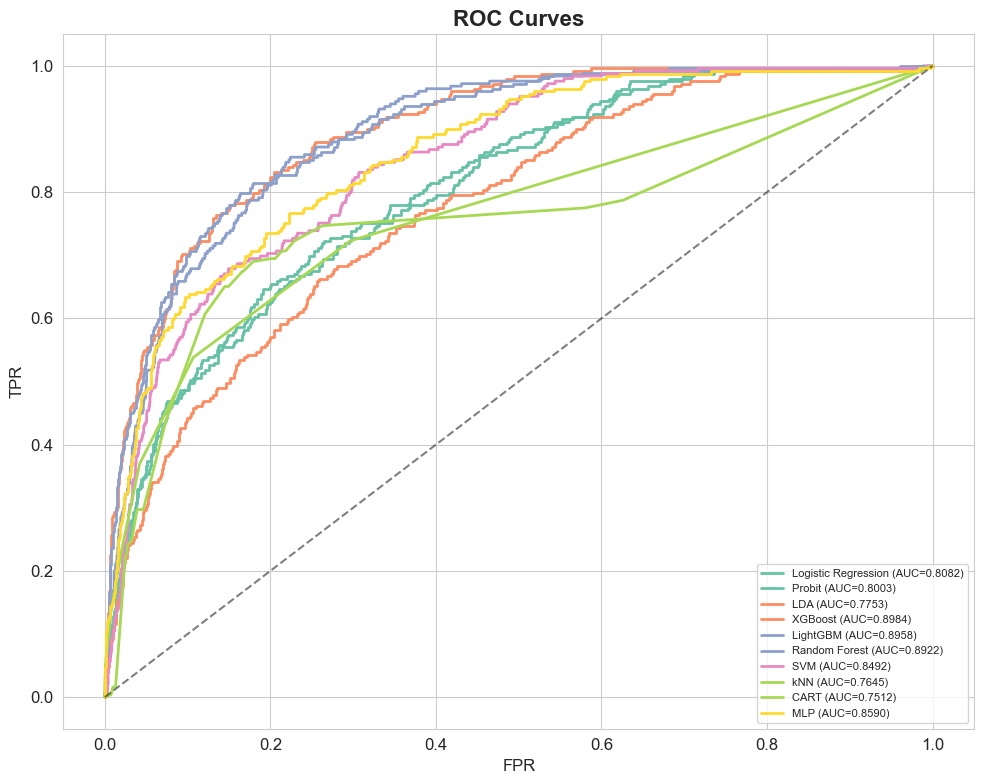

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
for i, (n, r) in enumerate(results.items()):
    fp, tp, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fp, tp, label=f"{n} (AUC={r['auc']:.4f})", color=colors_p[i], linewidth=2)
ax.plot([0,1],[0,1],'k--',alpha=0.5); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontsize=16, fontweight='bold'); ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

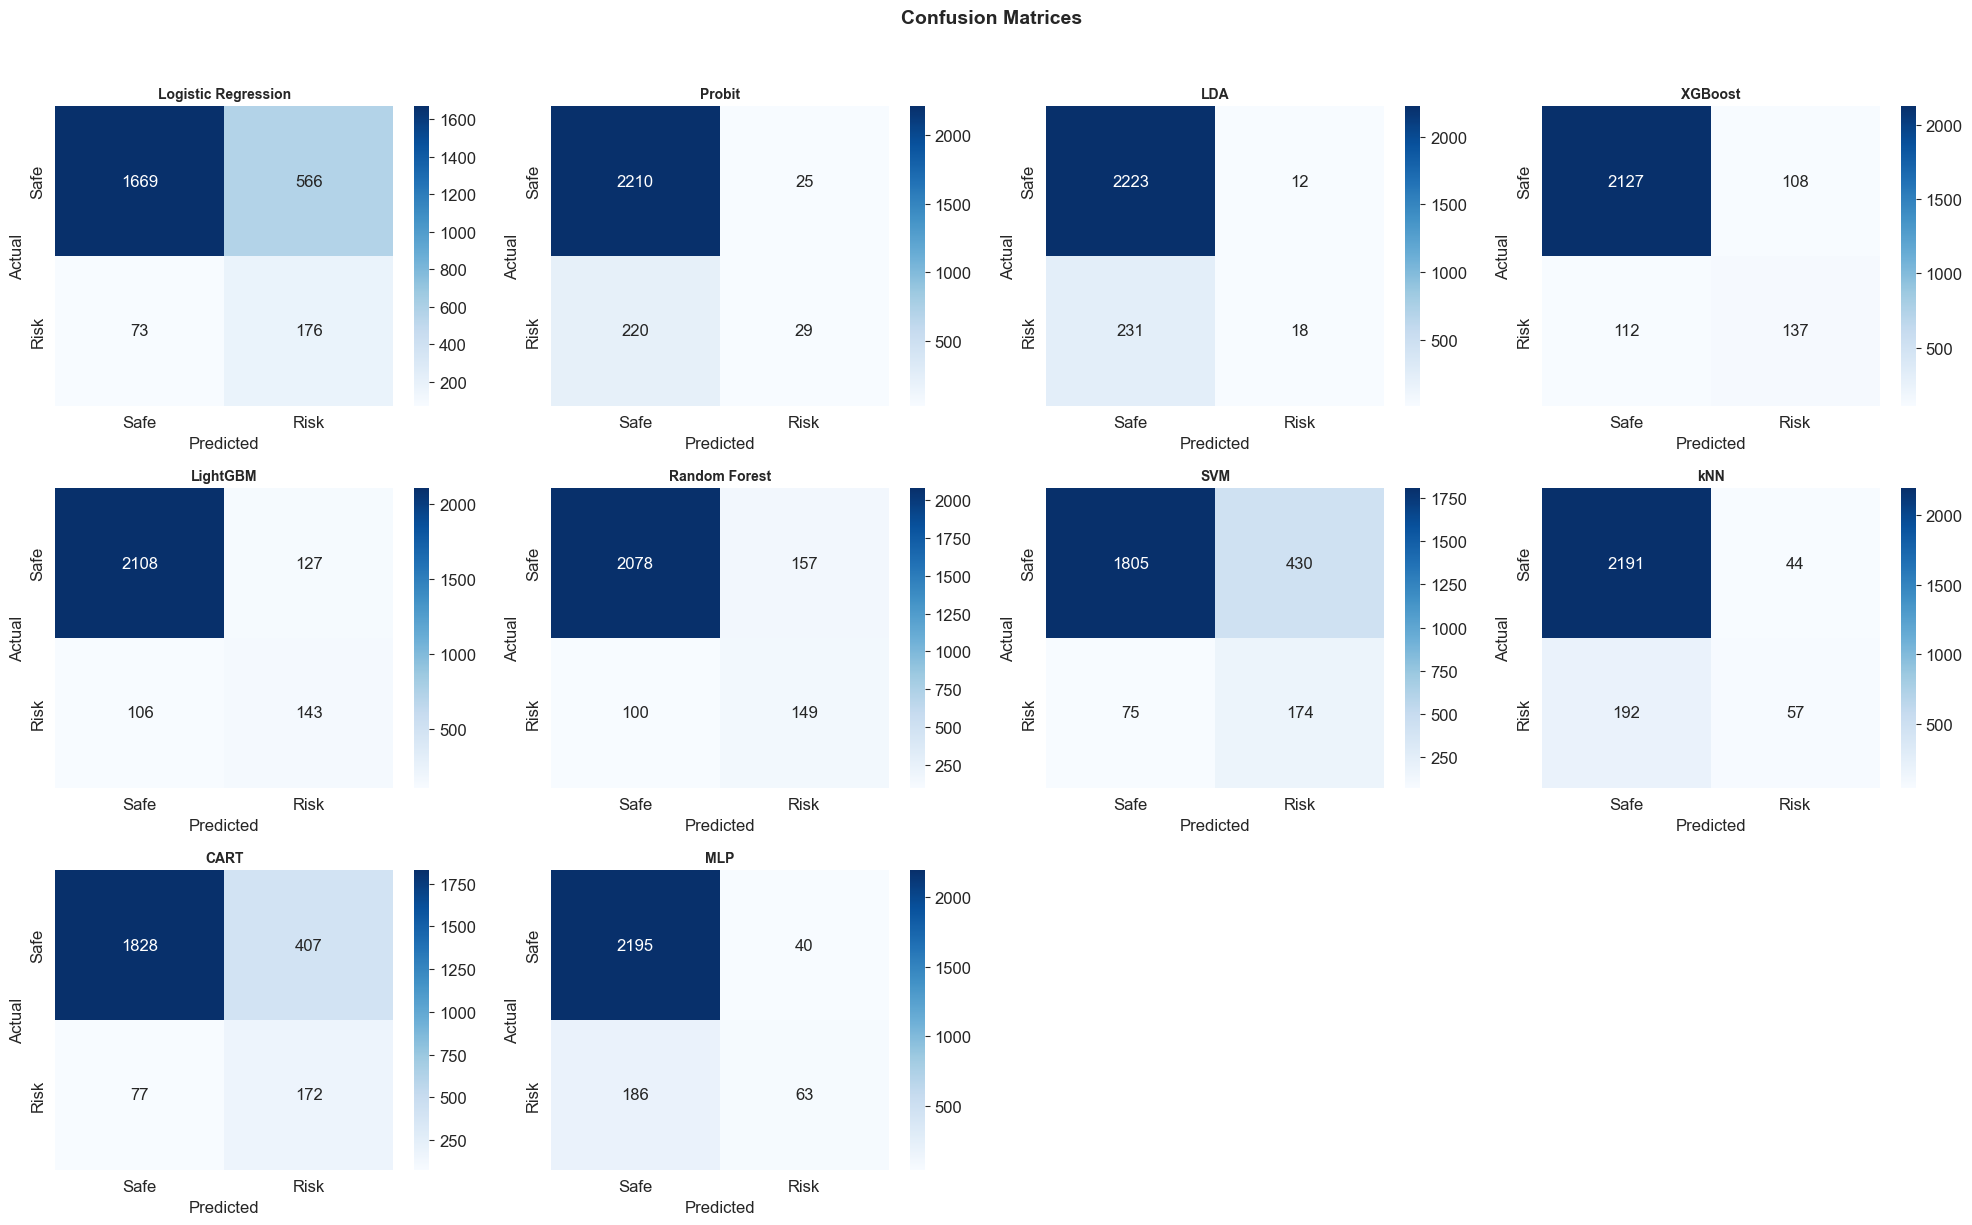

In [18]:
n=len(results); nc=4; nr=(n+nc-1)//nc
fig,axes=plt.subplots(nr,nc,figsize=(5*nc,4*nr)); axes=axes.flatten()
for i,(n,r) in enumerate(results.items()):
    cm=confusion_matrix(y_test,r['y_pred'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[i],xticklabels=['Safe','Risk'],yticklabels=['Safe','Risk'])
    axes[i].set_title(n,fontweight='bold',fontsize=10); axes[i].set_ylabel('Actual'); axes[i].set_xlabel('Predicted')
for j in range(i+1,len(axes)): axes[j].set_visible(False)
plt.suptitle('Confusion Matrices',fontsize=14,fontweight='bold',y=1.02); plt.tight_layout(); plt.show()

In [19]:
for n,r in results.items():
    print(f'\n=== {n} ({r["paradigm"]}) ==='); print(classification_report(y_test,r['y_pred'],target_names=['Safe','Risk']))


=== Logistic Regression (Econometric) ===
              precision    recall  f1-score   support

        Safe       0.96      0.75      0.84      2235
        Risk       0.24      0.71      0.36       249

    accuracy                           0.74      2484
   macro avg       0.60      0.73      0.60      2484
weighted avg       0.89      0.74      0.79      2484


=== Probit (Econometric) ===
              precision    recall  f1-score   support

        Safe       0.91      0.99      0.95      2235
        Risk       0.54      0.12      0.19       249

    accuracy                           0.90      2484
   macro avg       0.72      0.55      0.57      2484
weighted avg       0.87      0.90      0.87      2484


=== LDA (Econometric) ===
              precision    recall  f1-score   support

        Safe       0.91      0.99      0.95      2235
        Risk       0.60      0.07      0.13       249

    accuracy                           0.90      2484
   macro avg       0.75     

In [20]:
print('KS Statistic:')
for n,r in sorted(results.items(),key=lambda x:x[1]['ks'],reverse=True): print(f"  {n:25s} KS={r['ks']:.4f}")

KS Statistic:
  LightGBM                  KS=0.6363
  Random Forest             KS=0.6313
  XGBoost                   KS=0.6284
  MLP                       KS=0.5442
  SVM                       KS=0.5293
  CART                      KS=0.5109
  Logistic Regression       KS=0.4576
  Probit                    KS=0.4367
  kNN                       KS=0.4312
  LDA                       KS=0.4040


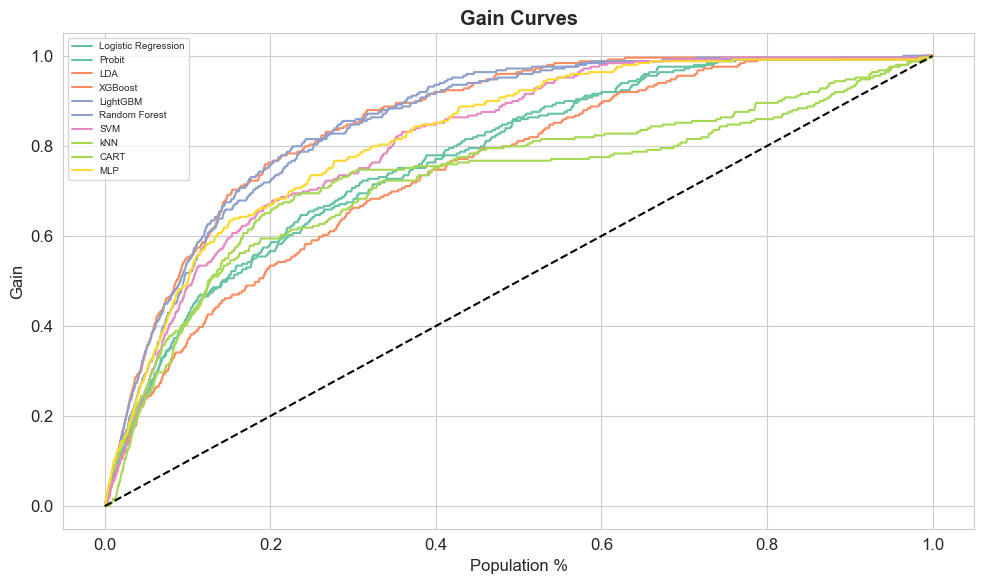

In [21]:
# Gain curve
fig, ax = plt.subplots(figsize=(10,6))
for i,(n,r) in enumerate(results.items()):
    si = np.argsort(-r['y_prob']); ys = y_test.values[si]
    cg = np.cumsum(ys)/ys.sum(); pp = np.arange(1,len(ys)+1)/len(ys)
    ax.plot(pp, cg, label=n, color=colors_p[i])
ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('Population %'); ax.set_ylabel('Gain')
ax.set_title('Gain Curves', fontweight='bold'); ax.legend(fontsize=7); plt.tight_layout(); plt.show()

---
## Phase 8 — Model Calibration

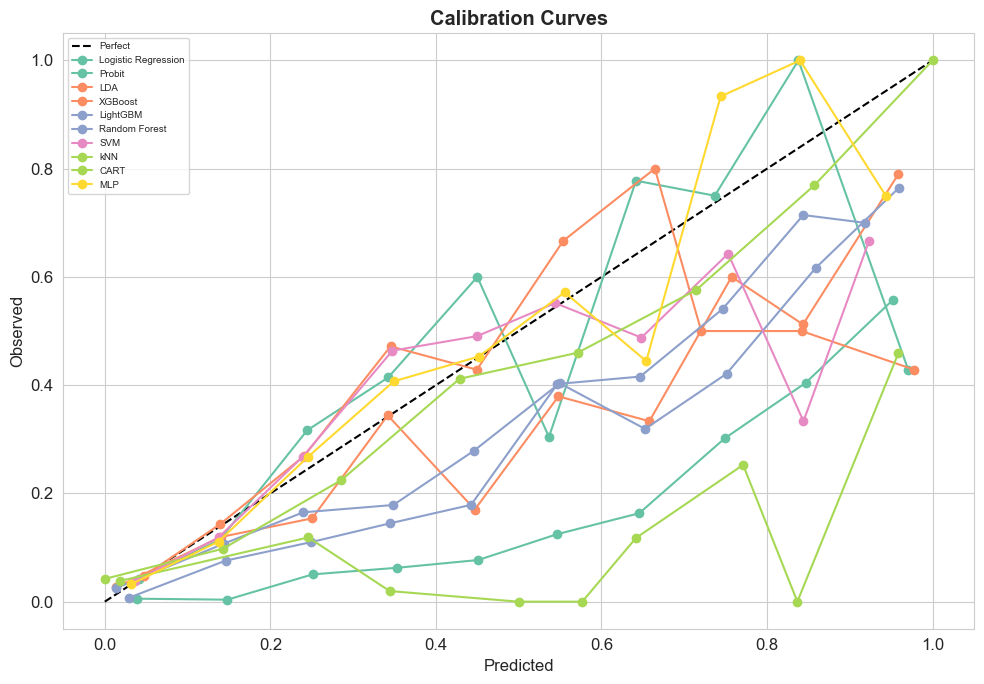

In [22]:
fig,ax=plt.subplots(figsize=(10,7)); ax.plot([0,1],[0,1],'k--',label='Perfect')
for i,(n,r) in enumerate(results.items()):
    try: pt,pp=calibration_curve(y_test,r['y_prob'],n_bins=10); ax.plot(pp,pt,marker='o',label=n,color=colors_p[i])
    except: pass
ax.set_xlabel('Predicted'); ax.set_ylabel('Observed'); ax.set_title('Calibration Curves',fontweight='bold')
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

In [23]:
print('Brier Score:')
for n,r in sorted(results.items(),key=lambda x:x[1]['brier']): print(f"  {n:25s} Brier={r['brier']:.6f}")

Brier Score:
  XGBoost                   Brier=0.067284
  MLP                       Brier=0.067614
  LightGBM                  Brier=0.069687
  SVM                       Brier=0.072593
  kNN                       Brier=0.076276
  Probit                    Brier=0.076468
  Random Forest             Brier=0.077641
  LDA                       Brier=0.080122
  CART                      Brier=0.141804
  Logistic Regression       Brier=0.176452


---
## Phase 9 — Post-Model Calibration

In [24]:
bml=max([k for k,v in results.items() if v['paradigm']=='ML'],key=lambda k:results[k]['auc'])
print(f'Post-calibration for: {bml}')
us=bml in ['SVM','kNN','MLP']; Xtr=X_train_scaled if us else X_train; Xte=X_test_scaled if us else X_test
for m,l in [('sigmoid','Platt'),('isotonic','Isotonic')]:
    try:
        b=results[bml]['model'].__class__(**results[bml]['model'].get_params())
        c=CalibratedClassifierCV(b,method=m,cv=3); c.fit(Xtr,y_train)
        yp=c.predict_proba(Xte)[:,1]; print(f'  {l}: Brier={brier_score_loss(y_test,yp):.6f} (orig: {results[bml]["brier"]:.6f})')
    except Exception as e: print(f'  {l}: Failed — {e}')

Post-calibration for: XGBoost
  Platt: Brier=0.061075 (orig: 0.067284)
  Isotonic: Brier=0.061302 (orig: 0.067284)


---
## Phase 10 — Interpretability (SHAP)

SHAP: XGBoost


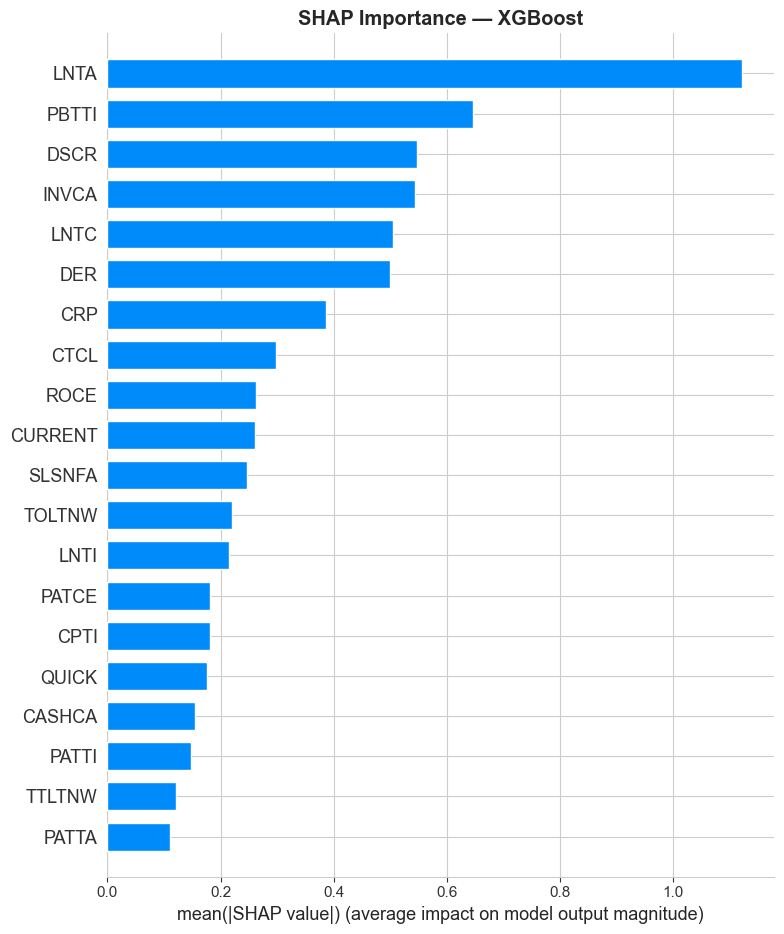

In [25]:
tm={k:v for k,v in results.items() if k in ['XGBoost','LightGBM','Random Forest','CART']}
bt=max(tm.keys(),key=lambda k:tm[k]['auc']); print(f'SHAP: {bt}')
exp=shap.TreeExplainer(results[bt]['model'])
Xs = X_test.sample(min(500,len(X_test)),random_state=42)
sv=exp.shap_values(Xs)
if isinstance(sv,list): sv=sv[1]
plt.figure(figsize=(10,8)); shap.summary_plot(sv,Xs,plot_type='bar',show=False)
plt.title(f'SHAP Importance — {bt}',fontweight='bold'); plt.tight_layout(); plt.show()

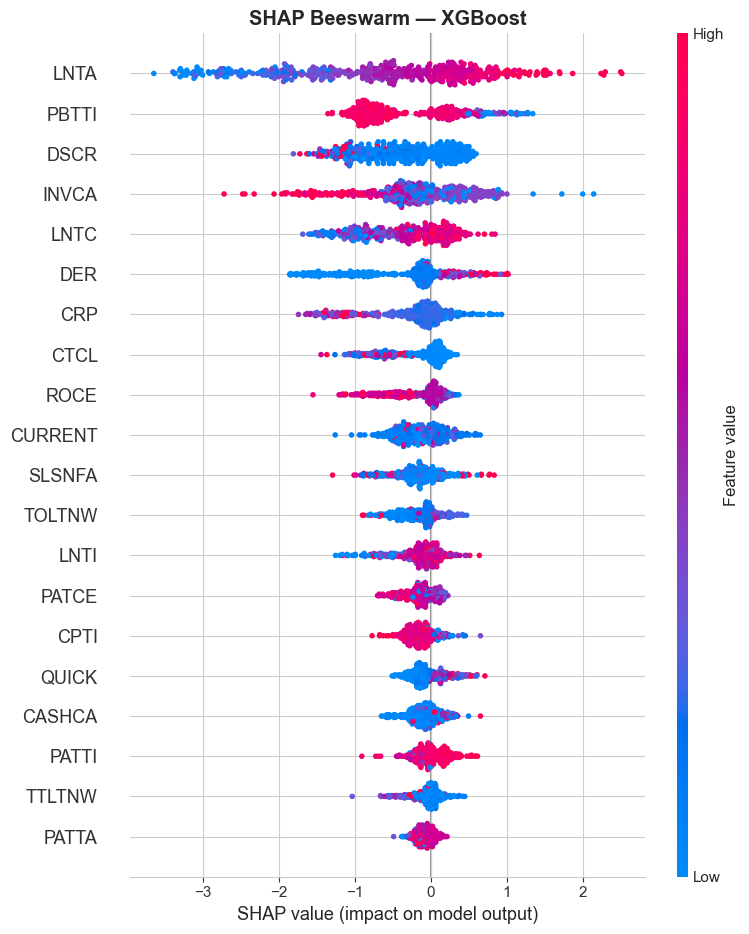

In [26]:
plt.figure(figsize=(10,8)); shap.summary_plot(sv,Xs,show=False)
plt.title(f'SHAP Beeswarm — {bt}',fontweight='bold'); plt.tight_layout(); plt.show()

---
## Phase 11 — Final Comparative Summary

In [27]:
comp=pd.DataFrame({k:[results[m][k] for m in results] for k in ['accuracy','auc','gini','ks','f1','precision','recall','brier']})
comp.insert(0,'Model',list(results.keys())); comp.insert(1,'Paradigm',[results[m]['paradigm'] for m in results])
comp=comp.sort_values('auc',ascending=False).reset_index(drop=True); comp.index+=1; comp.index.name='Rank'
print('=== FINAL COMPARISON — Mendeley Company Data (92K records) ==='); print(comp.to_string())

=== FINAL COMPARISON — Mendeley Company Data (92K records) ===
                    Model     Paradigm  accuracy       auc      gini        ks        f1  precision    recall     brier
Rank                                                                                                                   
1                 XGBoost           ML  0.911433  0.898403  0.796807  0.628387  0.554656   0.559184  0.550201  0.067284
2                LightGBM           ML  0.906200  0.895769  0.791538  0.636290  0.551060   0.529630  0.574297  0.069687
3           Random Forest           ML  0.896538  0.892165  0.784329  0.631261  0.536937   0.486928  0.598394  0.077641
4                     MLP           ML  0.909018  0.858992  0.717984  0.544249  0.357955   0.611650  0.253012  0.067614
5                     SVM           ML  0.796699  0.849200  0.698400  0.529274  0.407972   0.288079  0.698795  0.072593
6     Logistic Regression  Econometric  0.742754  0.808185  0.616370  0.457567  0.355197   0.2371

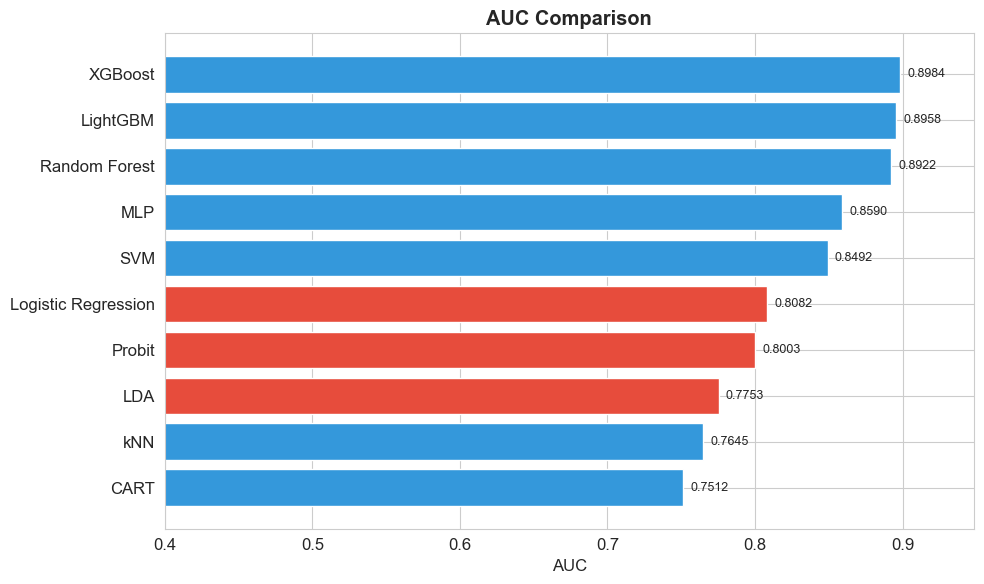

In [28]:
fig,ax=plt.subplots(figsize=(10,6))
pc={'Econometric':'#e74c3c','ML':'#3498db'}; bc=[pc.get(results[m]['paradigm'],'#95a5a6') for m in comp['Model']]
bars=ax.barh(comp['Model'],comp['auc'],color=bc); ax.set_xlabel('AUC')
ax.set_title('AUC Comparison',fontweight='bold'); ax.set_xlim([0.4,max(comp['auc'])+0.05]); ax.invert_yaxis()
for b,v in zip(bars,comp['auc']): ax.text(v+0.005,b.get_y()+b.get_height()/2,f'{v:.4f}',va='center',fontsize=9)
plt.tight_layout(); plt.show()

### Discussion

1. **Paradigm 1 (Econometric)**: Logistic Regression / Probit / LDA provide interpretable baselines with 23 financial ratios.
2. **Paradigm 2 (ML)**: XGBoost/LightGBM excel on this large dataset (92K records).
3. **Paradigm 3 (Structural)**: Impossible — no market data.
4. **Paradigm 4 (Dynamic)**: Impossible — no temporal dimension.
5. **Altman Z-Score**: Not applicable — ratios don't map to required components.

---
## End of Analysis